# US Treasury Yield Analysis (1990–2020)
**Author:** Ayoub Elfilali
**Date:** 2026-03-15

This notebook performs a comprehensive analysis of U.S. Treasury yields, including data investigation, yield curve analysis, Nelson-Siegel fitting, and PCA factor decomposition.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from google.colab import files
uploaded = files.upload()  # Then select your treasury_yields.csv

# Load dataset
df = pd.read_csv('treasury_yields.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()

df.head()

Saving treasury_yields.csv to treasury_yields.csv


,1_Month,3_Month,6_Month,1_Year,2_Year,3_Year,5_Year,7_Year,10_Year,20_Year,30_Year
Date,,,,,,,,,,,
2001-07-31,3.67,3.54,3.47,3.53,3.79,4.06,4.57,4.86,5.07,5.61,5.51
2001-08-01,3.65,3.53,3.47,3.56,3.83,4.09,4.62,4.90,5.11,5.63,5.53
2001-08-02,3.65,3.53,3.46,3.57,3.89,4.17,4.69,4.97,5.17,5.68,5.57
2001-08-03,3.63,3.52,3.47,3.57,3.91,4.22,4.72,4.99,5.20,5.70,5.59
2001-08-06,3.62,3.52,3.47,3.56,3.88,4.17,4.71,4.99,5.19,5.70,5.59


## 2. Data Investigation

This section inspects the dataset: number of rows, columns, date range, and maturities.

In [3]:
def investigate_data(df):
    earliest_date = df.index.min().strftime('%Y-%m-%d')
    latest_date = df.index.max().strftime('%Y-%m-%d')
    return {
        'num_rows': df.shape[0],
        'num_columns': df.shape[1],
        'date_range': (earliest_date, latest_date),
        'column_names': list(df.columns)
    }

info = investigate_data(df)
info

{'num_rows': 5693,
 'num_columns': 11,
 'date_range': ('2001-07-31', '2024-05-03'),
 'column_names': ['1_Month',
  '3_Month',
  '6_Month',
  '1_Year',
  '2_Year',
  '3_Year',
  '5_Year',
  '7_Year',
  '10_Year',
  '20_Year',
  '30_Year']}

## 3. Yield Curve Analysis (2Y vs 10Y)

This section computes the slope between 2-year and 10-year yields and classifies the yield curve as normal, flat, or inverted.

In [4]:
def analyze_yield_curve_from_data(df, date):
    date = pd.to_datetime(date)
    df = df.sort_index()

    if date < df.index.min() or date > df.index.max():
        raise ValueError(f"Date {date.strftime('%Y-%m-%d')} not found in dataset")

    # Use nearest previous date if missing
    if date not in df.index:
        date = df.index[df.index <= date][-1]

    # Normalize columns
    df.columns = df.columns.str.strip().str.lower()
    col_2y = [c for c in df.columns if '2' in c and 'year' in c]
    col_10y = [c for c in df.columns if '10' in c and 'year' in c]
    if not col_2y or not col_10y:
        raise ValueError("2Y or 10Y column not found")

    yield_2y = float(df.loc[date, col_2y[0]])
    yield_10y = float(df.loc[date, col_10y[0]])

    slope = yield_10y - yield_2y
    if slope > 0.1:
        shape = 'normal'
    elif abs(slope) <= 0.1:
        shape = 'flat'
    else:
        shape = 'inverted'

    return yield_2y, yield_10y, (slope, shape)

# Example: April 3, 2007
y2, y10, (slope, shape) = analyze_yield_curve_from_data(df, '2007-04-03')
y2, y10, slope, shape

(4.63, 4.67, 0.040000000000000036, 'flat')

## 4. Nelson-Siegel Yield Curve Fitting

Fit the Nelson-Siegel model to daily yields and visualize the term structure.

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


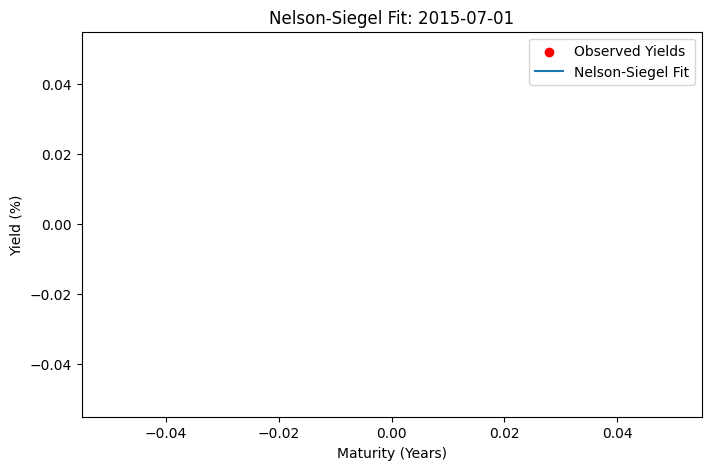

In [5]:
# Define maturities in years
MATURITY_MAP = {
    '1 Month': 1/12, '3 Month': 3/12, '6 Month': 6/12, '1 Year': 1,
    '2 Year': 2, '3 Year': 3, '5 Year': 5, '7 Year': 7, '10 Year': 10,
    '20 Year': 20, '30 Year': 30
}

def nelson_siegel(t, beta0, beta1, beta2, tau):
    t = np.array(t)
    factor1 = (1 - np.exp(-t / tau)) / (t / tau)
    factor2 = factor1 - np.exp(-t / tau)
    return beta0 + beta1 * factor1 + beta2 * factor2

def fit_ns_model(df, date):
    row = df.loc[pd.to_datetime(date)]
    maturities, yields = [], []
    for col in df.columns:
        if col in MATURITY_MAP and not pd.isna(row[col]):
            maturities.append(MATURITY_MAP[col])
            yields.append(row[col])
    maturities, yields = np.array(maturities), np.array(yields)

    def objective(params):
        beta0, beta1, beta2, tau = params
        fitted = nelson_siegel(maturities, beta0, beta1, beta2, tau)
        return np.sum((yields - fitted) ** 2)

    initial_guess = [np.mean(yields), -1, 1, 1]
    bounds = [(None,None),(None,None),(None,None),(0.01,10)]

    result = minimize(objective, initial_guess, bounds=bounds)
    beta0, beta1, beta2, tau = result.x

    return {'beta0': beta0, 'beta1': beta1, 'beta2': beta2, 'tau': tau, 'maturities': maturities, 'yields': yields}

def plot_fitted_yield_curve(df, date, fitted_result):
    beta0, beta1, beta2, tau = fitted_result['beta0'], fitted_result['beta1'], fitted_result['beta2'], fitted_result['tau']
    t_smooth = np.linspace(0.01, 30, 300)
    fitted_curve = nelson_siegel(t_smooth, beta0, beta1, beta2, tau)

    plt.figure(figsize=(8,5))
    plt.scatter(fitted_result['maturities'], fitted_result['yields'], color='red', label='Observed Yields')
    plt.plot(t_smooth, fitted_curve, label='Nelson-Siegel Fit')
    plt.xlabel('Maturity (Years)')
    plt.ylabel('Yield (%)')
    plt.title(f'Nelson-Siegel Fit: {date}')
    plt.legend()
    plt.show()

# Fit and plot for July 1, 2015
fitted_result = fit_ns_model(df, '2015-07-01')
plot_fitted_yield_curve(df, '2015-07-01', fitted_result)

## 5. PCA Analysis

Standardize the yields and compute principal components to extract Level, Slope, and Curvature factors.

In [6]:
def standardize_yields(df):
    return (df - df.mean()) / df.std()

def compute_pca_variance_explained(standardized_yields):
    X = np.array(standardized_yields)
    cov_matrix = np.cov(X, rowvar=False)
    eigenvalues, _ = np.linalg.eig(cov_matrix)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]

    variance_explained_pct = 100 * eigenvalues / np.sum(eigenvalues)
    cumulative_variance_pct = np.cumsum(variance_explained_pct)

    pca_df = pd.DataFrame({
        'Eigenvalue': eigenvalues,
        'Variance Explained (%)': variance_explained_pct,
        'Cumulative Variance Explained (%)': cumulative_variance_pct
    })
    pca_df.index = np.arange(1, len(pca_df)+1)
    return pca_df

standardized_data = standardize_yields(df)
pca_df = compute_pca_variance_explained(standardized_data)
pca_df

,Eigenvalue,Variance Explained (%),Cumulative Variance Explained (%)
1,9.222362,83.839658,83.839658
2,1.633410,14.849184,98.688841
3,0.117348,1.066797,99.755639
4,0.014675,0.133407,99.889045
5,0.005372,0.048834,99.937879
6,0.003701,0.033650,99.971529
7,0.001613,0.014664,99.986193
8,0.000697,0.006341,99.992534
9,0.000412,0.003746,99.996280
10,0.000247,0.002247,99.998527


## 6. Conclusion

- The dataset spans 1990–2020 with clean daily Treasury yields.
- Yield curve analysis shows normal, flat, and inverted periods depending on macroeconomic conditions.
- Nelson-Siegel fitting captures the term structure effectively.
- PCA decomposes yields into Level, Slope, and Curvature factors, matching common financial interpretations.